In [3]:
import torch
import mylib
import torch.nn as nn

from torch.utils import data

In [19]:
def train_concise(wd):
    net = nn.Sequential(nn.Linear(num_inputs, 1))
    for param in net.parameters():
        param.data.normal_()
    loss = nn.MSELoss(reduction='none')
    num_epochs, lr = 100, 0.003
    # bias不衰减
    trainer = torch.optim.SGD([
        {"params":net[0].weight,'weight_decay': wd},
        {"params":net[0].bias}], lr=lr)
    animator = mylib.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.mean().backward()
            trainer.step()
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1,
                         (mylib.evaluate_loss(net, train_iter, loss),
                         mylib.evaluate_loss(net, test_iter, loss)))
    # .item() 是一个张量（Tensor）的方法，用于将只包含一个元素的张量转换为一个 Python 标准数值
    print('w的L2范数: ', net[0].weight.norm().item())



def synthetic_data(w, b, num_examples):
    # 构造随机数据y = Xw + b + e
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = X @ w + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1,1))

def load_array(data_arrays, batch_size, is_train=True):
    """构造一个PyTorch数据迭代器"""
    # is_train表示是否希望数据迭代器对象在每个迭代周期内打乱数据
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size, shuffle=is_train)

w的L2范数:  14.228446960449219


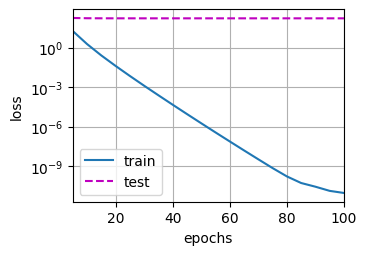

In [23]:
n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05
train_data = synthetic_data(true_w, true_b, n_train)
train_iter = load_array(train_data, batch_size)
test_data = synthetic_data(true_w, true_b, n_test)
test_iter = load_array(test_data, batch_size, is_train=False)

train_concise(wd=0)

w的L2范数:  0.37710994482040405


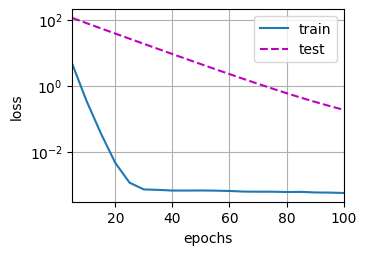

In [24]:
train_concise(wd=3)

In [ ]:
a = torch.tensor([1,2,3],dtype=float)
print(a)
print(a.norm())

tensor([1., 2., 3.], dtype=torch.float64)
tensor(14., dtype=torch.float64)
